# Gradient Sports API — Exemplos de Uso

Importa o cliente de `gradient_client.py`.  
A autenticação é lida automaticamente do arquivo `.env` (`BEARER_TOKEN`).

In [72]:
import pandas as pd
import sys
from pathlib import Path
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px

sys.path.append(str(Path().resolve().parent.parent))
from src.gradient_client import GradientSportsClient

pd.set_option('display.max_columns', None)

### Status da requisição

In [73]:
client = GradientSportsClient()

# health check
client.get_status()

{'data': {'status': 'ok'}}

### Competições

In [74]:
df_competitions = pd.read_csv(str(Path().resolve().parent.parent / "data" / "competitions.csv"))
df_competitions

,season,competition.id,competition.name
0,2020-2021,1,Premier League
1,2021-2022,1,Premier League
2,2022-2023,1,Premier League
3,2023-2024,1,Premier League
4,2024-2025,1,Premier League
5,2025-2026,1,Premier League
6,2023,42,Brasileiro Série A
7,2024,42,Brasileiro Série A
8,2025,42,Brasileiro Série A
9,2026,42,Brasileiro Série A


- Existem dados de duas competições, Premier League e Brasileiro Série A.
- Dentre essas competições, existem dados de 6 temporadas da Premier League e 4 temporadas do Brasileiro Série A.
- Não parecem haver incosistências nos dados de competições.

### Times

In [75]:
# teams the account can access
df_teams = pd.read_csv(str(Path().resolve().parent.parent / "data" / "teams.csv"))
df_teams

,team.id,team.name,competition.id,competition.name
0,1.0,AFC Bournemouth,1,Premier League
1,20.0,Wolverhampton Wanderers,1,Premier League
2,221.0,Nottingham Forest,1,Premier League
3,335.0,Sunderland AFC,1,Premier League
4,10.0,Liverpool,1,Premier League
5,218.0,Luton Town,1,Premier League
6,7.0,Crystal Palace,1,Premier League
7,16.0,Southampton,1,Premier League
8,55.0,Leeds United,1,Premier League
9,13.0,Newcastle United,1,Premier League


In [76]:
df_teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 59 entries, 0 to 58
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   team.id           57 non-null     float64
 1   team.name         57 non-null     str    
 2   competition.id    59 non-null     int64  
 3   competition.name  59 non-null     str    
dtypes: float64(1), int64(1), str(2)
memory usage: 2.0 KB


In [77]:
df_teams.duplicated('team.id').sum()

np.int64(1)

- O dataset de times possui duas colunas com ids dos times nulas e uma duplicata.

In [78]:
df_teams[df_teams.duplicated('team.id', keep=False)]

,team.id,team.name,competition.id,competition.name
23,NaN,NaN,1,Premier League
55,NaN,NaN,42,Brasileiro Série A


- As duas duplicatas são NaN em competições diferentes, ao mesmo tempo que é o gerador de duplicata. Ambos devem ser removidos.

In [79]:
df_teams = df_teams[df_teams['team.id'].notna()].reset_index(drop=True)

In [80]:
df_teams.to_csv(str(Path().resolve().parent.parent / "data" / "teams.csv"), index=False)

In [81]:
df_teams['competition.name'].value_counts()

competition.name
Brasileiro Série A    29
Premier League        28
Name: count, dtype: int64

- Entre as temporadas, existem dados de 28 times da Premier League e 29 do Brasileirão.

### Jogos

In [82]:
# all games — or filter by season / competition / team
# as_dataframe=True → one row per game, nested dicts dot-expanded
games = pd.read_csv(str(Path().resolve().parent.parent / "data" / "games.csv"))
games

,id,date,season,teamExtraTimeStartSide,teamStartSide,venueType,team.id,team.name,competition.id,competition.name,opponentTeam.id,opponentTeam.name,stadium.name,stadium.length,stadium.width
0,40876,2025-08-17,2025-2026,Left,Right,OPPONENT_HOME,2,Arsenal,1,Premier League,12,Manchester United,Old Trafford,105.0,68.0
1,4447,2022-08-13,2022-2023,Right,Left,TEAM_HOME,3,Aston Villa,1,Premier League,8,Everton,Villa Park,105.0,68.0
2,4760,2023-04-25,2022-2023,Left,Left,OPPONENT_HOME,7,Crystal Palace,1,Premier League,20,Wolverhampton Wanderers,Molineux,105.0,68.0
3,12806,2023-11-04,2023,Left,Right,OPPONENT_HOME,517,Bahia,42,Brasileiro Série A,515,Grêmio,Arena do Grêmio,105.0,68.0
4,32206,2025-01-18,2024-2025,Right,Left,TEAM_HOME,119,Brentford,1,Premier League,10,Liverpool,Gtech Community Stadium,105.0,68.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3407,231,2020-11-21,2020-2021,Right,Left,TEAM_HOME,3,Aston Villa,1,Premier League,4,Brighton & Hove Albion,Villa Park,105.0,68.0
3408,4660,2023-02-12,2022-2023,Right,Left,TEAM_HOME,55,Leeds United,1,Premier League,12,Manchester United,Elland Road,105.0,68.0
3409,1224,2021-12-04,2021-2022,Left,Left,OPPONENT_HOME,10,Liverpool,1,Premier League,20,Wolverhampton Wanderers,Molineux,105.0,68.0
3410,12744,2023-09-30,2023,Right,Right,TEAM_HOME,437,Fortaleza,42,Brasileiro Série A,515,Grêmio,Arena Castelao,105.0,68.0


In [83]:
games.info()

<class 'pandas.DataFrame'>
RangeIndex: 3412 entries, 0 to 3411
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      3412 non-null   int64  
 1   date                    3412 non-null   str    
 2   season                  3412 non-null   str    
 3   teamExtraTimeStartSide  3412 non-null   str    
 4   teamStartSide           3412 non-null   str    
 5   venueType               3412 non-null   str    
 6   team.id                 3412 non-null   int64  
 7   team.name               3412 non-null   str    
 8   competition.id          3412 non-null   int64  
 9   competition.name        3412 non-null   str    
 10  opponentTeam.id         3412 non-null   int64  
 11  opponentTeam.name       3412 non-null   str    
 12  stadium.name            3412 non-null   str    
 13  stadium.length          3412 non-null   float64
 14  stadium.width           3412 non-null   float64
dty

In [84]:
games.duplicated('id').sum()

np.int64(0)

- O conjunto de dados de jogos não possui linhas duplicadas ou dados ausentes.

In [85]:
games['competition.name'].value_counts()

competition.name
Premier League        2205
Brasileiro Série A    1207
Name: count, dtype: int64

- Existem 2205 partidas da Premier League e 1207 do Brasileirão.

In [87]:
games[['competition.name', 'season']].value_counts().sort_index()

competition.name    season   
Brasileiro Série A  2023         377
                    2024         376
                    2025         379
                    2026          75
Premier League      2020-2021    378
                    2021-2022    377
                    2022-2023    380
                    2023-2024    381
                    2024-2025    380
                    2025-2026    309
Name: count, dtype: int64

- Nota-se que os dados não apresentam redundâncias (exemplo: Time A x Time B / Time B x Time A) e completam 380 partidas, no máximo.
- Na temporada 2023-2024 há um dado a mais, indicando uma incosistência nos dados.
- Existem temporadas faltando dados, exceto 2025-2026 (Premier League) e 2026 (Brasileirão) que ainda estão em andamento.

In [88]:
def expand_teams(df):
    df_home = df[["season", "competition.name", "team.name"]].rename(
        columns={"team.name": "team"}
    )

    df_away = df[["season", "competition.name", "opponentTeam.name"]].rename(
        columns={"opponentTeam.name": "team"}
    )

    return pd.concat([df_home, df_away], ignore_index=True)


games_expanded = expand_teams(games)


# 1. FILTROS + AGREGAÇÃO
df_pl = (
    games_expanded[games_expanded["competition.name"] == "Premier League"]
    .groupby(["season", "team"])
    .size()
    .reset_index(name="matches")
)

df_br = (
    games_expanded[games_expanded["competition.name"] == "Brasileiro Série A"]
    .groupby(["season", "team"])
    .size()
    .reset_index(name="matches")
)

# 2. REMOVER ÚLTIMA TEMPORADA
df_pl = df_pl[df_pl["season"] != df_pl["season"].max()]
df_br = df_br[df_br["season"] != df_br["season"].max()]

# 3. PIVOT
df_pl_pivot = df_pl.pivot(index="team", columns="season", values="matches")
df_br_pivot = df_br.pivot(index="team", columns="season", values="matches")

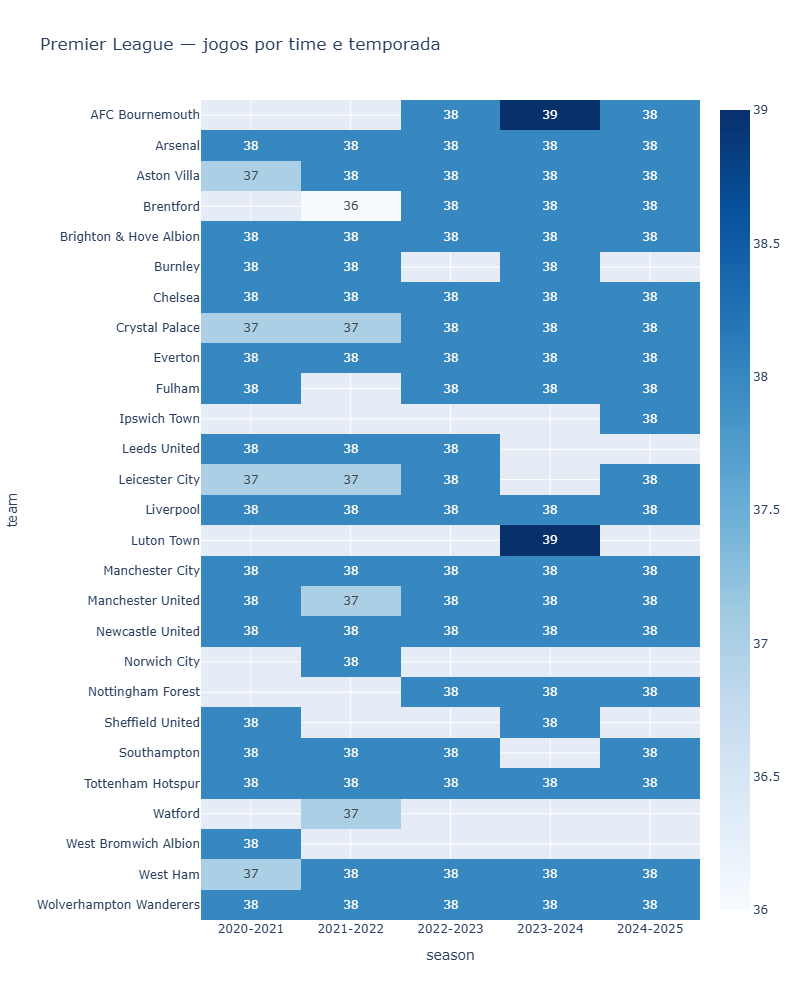

In [89]:
fig_pl = px.imshow(
    df_pl_pivot,
    aspect="auto",
    text_auto=True,
    color_continuous_scale="Blues",
    title="Premier League — jogos por time e temporada",
)

fig_pl.update_layout(
    height=1000,
    width=800
)

fig_pl.show('png')

- Pode-se notar que, conforme as temporadas disponiveis, a distribuição de dados disponíveis dos times aparenta ter completude nos dados, salvo exceções.
- Alguns momentos há dados faltantes, como casos com 36 ou 37 jogos. 
- Curiosamente, o time AFC Bournemouth e Luton Town tiveram uma partida a mais na temporada 2023-2024, ou seja, uma inconsistência nos dados.
- Não foi incluída a última temporada (2025-2026) pois os dados seguem em atualização devido a temporada não ter sido concluída.

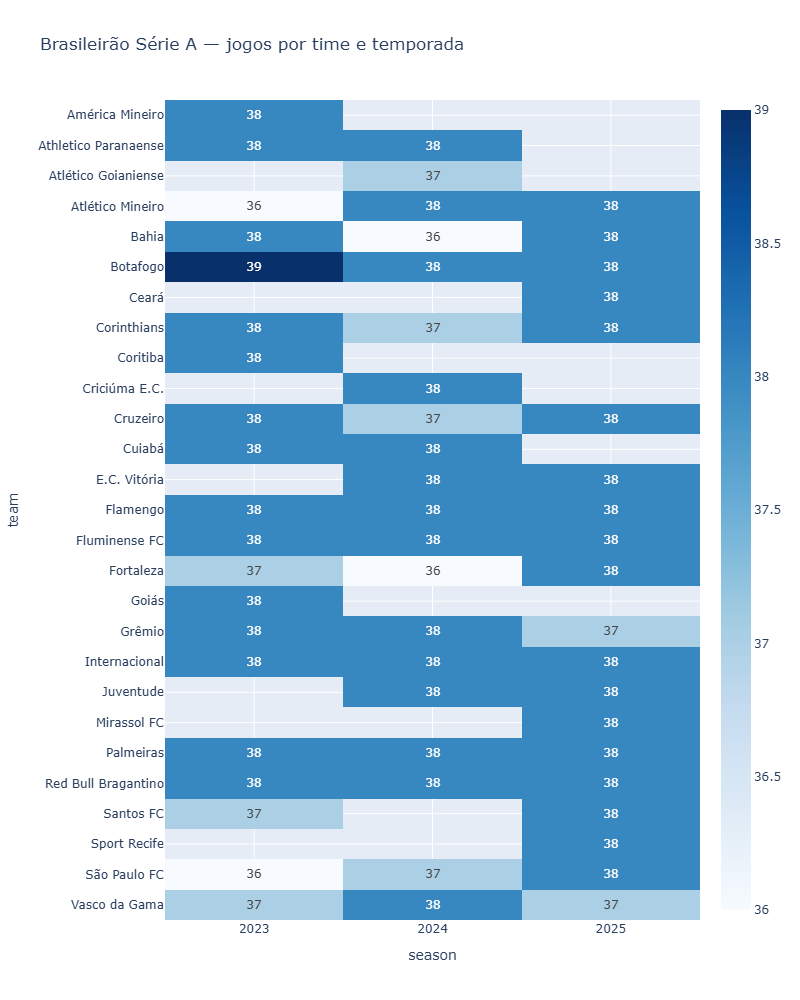

In [90]:
fig_br = px.imshow(
    df_br_pivot,
    aspect="auto",
    text_auto=True,
    color_continuous_scale="Blues",
    title="Brasileirão Série A — jogos por time e temporada"
)

fig_br.update_layout(
    height=1000,
    width=800
)

fig_br.show('png')

- Assim como os dados da Premier League, há times com uma ou duas partidas a menos de dados. Porém, de forma geral, sugere-se haver uma completude de registros dos jogos.
- Também nota-se que o Botafogo em 2023 possui um registro a mais de partida, apontando uma incosistência nos dados também.
- Não foi incluída a última temporada (2025-2026) pois os dados seguem em atualização devido a temporada não ter sido concluída.

In [91]:
games.loc[(games['season'] == '2023-2024') & 
          ((games['team.name'] == 'AFC Bournemouth') | 
           (games['opponentTeam.name'] == 'AFC Bournemouth')), ['team.name', 'opponentTeam.name']].melt().value_counts('value')

value
AFC Bournemouth            39
Luton Town                  3
Brighton & Hove Albion      2
Everton                     2
Brentford                   2
West Ham                    2
Liverpool                   2
Chelsea                     2
Manchester United           2
Tottenham Hotspur           2
Crystal Palace              2
Newcastle United            2
Sheffield United            2
Fulham                      2
Wolverhampton Wanderers     2
Nottingham Forest           2
Burnley                     2
Aston Villa                 2
Manchester City             2
Arsenal                     2
Name: count, dtype: int64

In [92]:
games.loc[(games['season'] == '2023-2024') & 
          (((games['team.name'] == 'AFC Bournemouth') | 
           (games['opponentTeam.name'] == 'AFC Bournemouth')) &
          ((games['team.name'] == 'Luton Town') | 
           (games['opponentTeam.name'] == 'Luton Town')))]

,id,date,season,teamExtraTimeStartSide,teamStartSide,venueType,team.id,team.name,competition.id,competition.name,opponentTeam.id,opponentTeam.name,stadium.name,stadium.length,stadium.width
1278,13496,2023-12-16,2023-2024,Right,Right,TEAM_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Vitality Stadium,105.0,68.0
2182,13650,2024-04-06,2023-2024,Left,Left,OPPONENT_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Kenilworth Road,100.0,66.0
3158,20480,2024-03-13,2023-2024,Right,Right,TEAM_HOME,1,AFC Bournemouth,1,Premier League,218,Luton Town,Vitality Stadium,105.0,68.0


- Nota-se que um dos registros está incosistente pela data e gerou uma duplicata. A data '2023-12-16' está incorreta, já que esse jogo foi em '2024-03-13'.
- Como o registro a mais envolve os dois times com um jogo a mais, remover essa duplicata iria corrigir o jogo a mais tanto do AFC Bournemouth quanto do Luton Town.

In [93]:
# Remoção da incosistência
games.drop(games[games['id'] == 13496].index, axis=0, inplace=True)

In [94]:
games.loc[(games['season'] == '2023') & 
          ((games['team.name'] == 'Botafogo') | 
           (games['opponentTeam.name'] == 'Botafogo')), ['team.name', 'opponentTeam.name']].melt().value_counts('value')

value
Botafogo                39
Athletico Paranaense     3
América Mineiro          2
Atlético Mineiro         2
Bahia                    2
Vasco da Gama            2
Goiás                    2
Red Bull Bragantino      2
Fluminense FC            2
Coritiba                 2
Grêmio                   2
São Paulo FC             2
Flamengo                 2
Santos FC                2
Corinthians              2
Cruzeiro                 2
Internacional            2
Fortaleza                2
Cuiabá                   2
Palmeiras                2
Name: count, dtype: int64

In [95]:
games.loc[(games['season'] == '2023') & 
          (((games['team.name'] == 'Botafogo') | 
           (games['opponentTeam.name'] == 'Botafogo')) &
          ((games['team.name'] == 'Athletico Paranaense') | 
           (games['opponentTeam.name'] == 'Athletico Paranaense')))]

,id,date,season,teamExtraTimeStartSide,teamStartSide,venueType,team.id,team.name,competition.id,competition.name,opponentTeam.id,opponentTeam.name,stadium.name,stadium.length,stadium.width
486,12578,2023-06-03,2023,Right,Right,TEAM_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Arena da Baixada,105.0,68.0
1376,12766,2023-10-22,2023,Left,Right,OPPONENT_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Estádio Olímpico Nilton Santos,105.0,68.0
2516,20421,2023-10-22,2023,Left,Right,OPPONENT_HOME,426,Athletico Paranaense,42,Brasileiro Série A,430,Botafogo,Estádio Olímpico Nilton Santos,105.0,68.0


- Nota-se que um dos registros está incosistente pelo id e gerou uma duplicata. Seria necessário remover um dos dois registros para corrigir a incosistência.

In [96]:
# Remoção da incosistência
games.drop(games[games['id'] == 20421].index, axis=0, inplace=True)

In [97]:
games.reset_index(drop=True).to_csv(str(Path().resolve().parent.parent / "data" / "games.csv"), index=False)